## Coloured noise vs white noise for $N = 2$

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import random_growth_src.lib as lib

plt.style.use("../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

## Run simulations

In [4]:
#Simulation settings
n_steps = int(5e4)
n_runs = int(2e4)
t_max = 500
dt = t_max/n_steps

#Model parameters
x0 = np.full(n_runs, np.log10(1))
M = 0.1

#White noise run
D_white = 10
sim_step_white = partial(lib.two_patch_x_white_noise_step, M=M, D=D_white)
results_x_white, results_t =  lib.run_simulation(x0, t_max, n_runs, n_steps, sim_step_white)

#Colored noise run
lamb = 1
D_coloured = 10
eta0 = np.full(n_runs, 0.0)

sim_step_coloured = partial(lib.two_patch_x_coloured_noise_step, M=M, D=D_coloured, lamb=lamb)
results_x_coloured, results_t =  lib.run_simulation(x0, t_max, n_runs, n_steps, sim_step_coloured, eta0=eta0)

## Figure 2)

### Figure 2a)

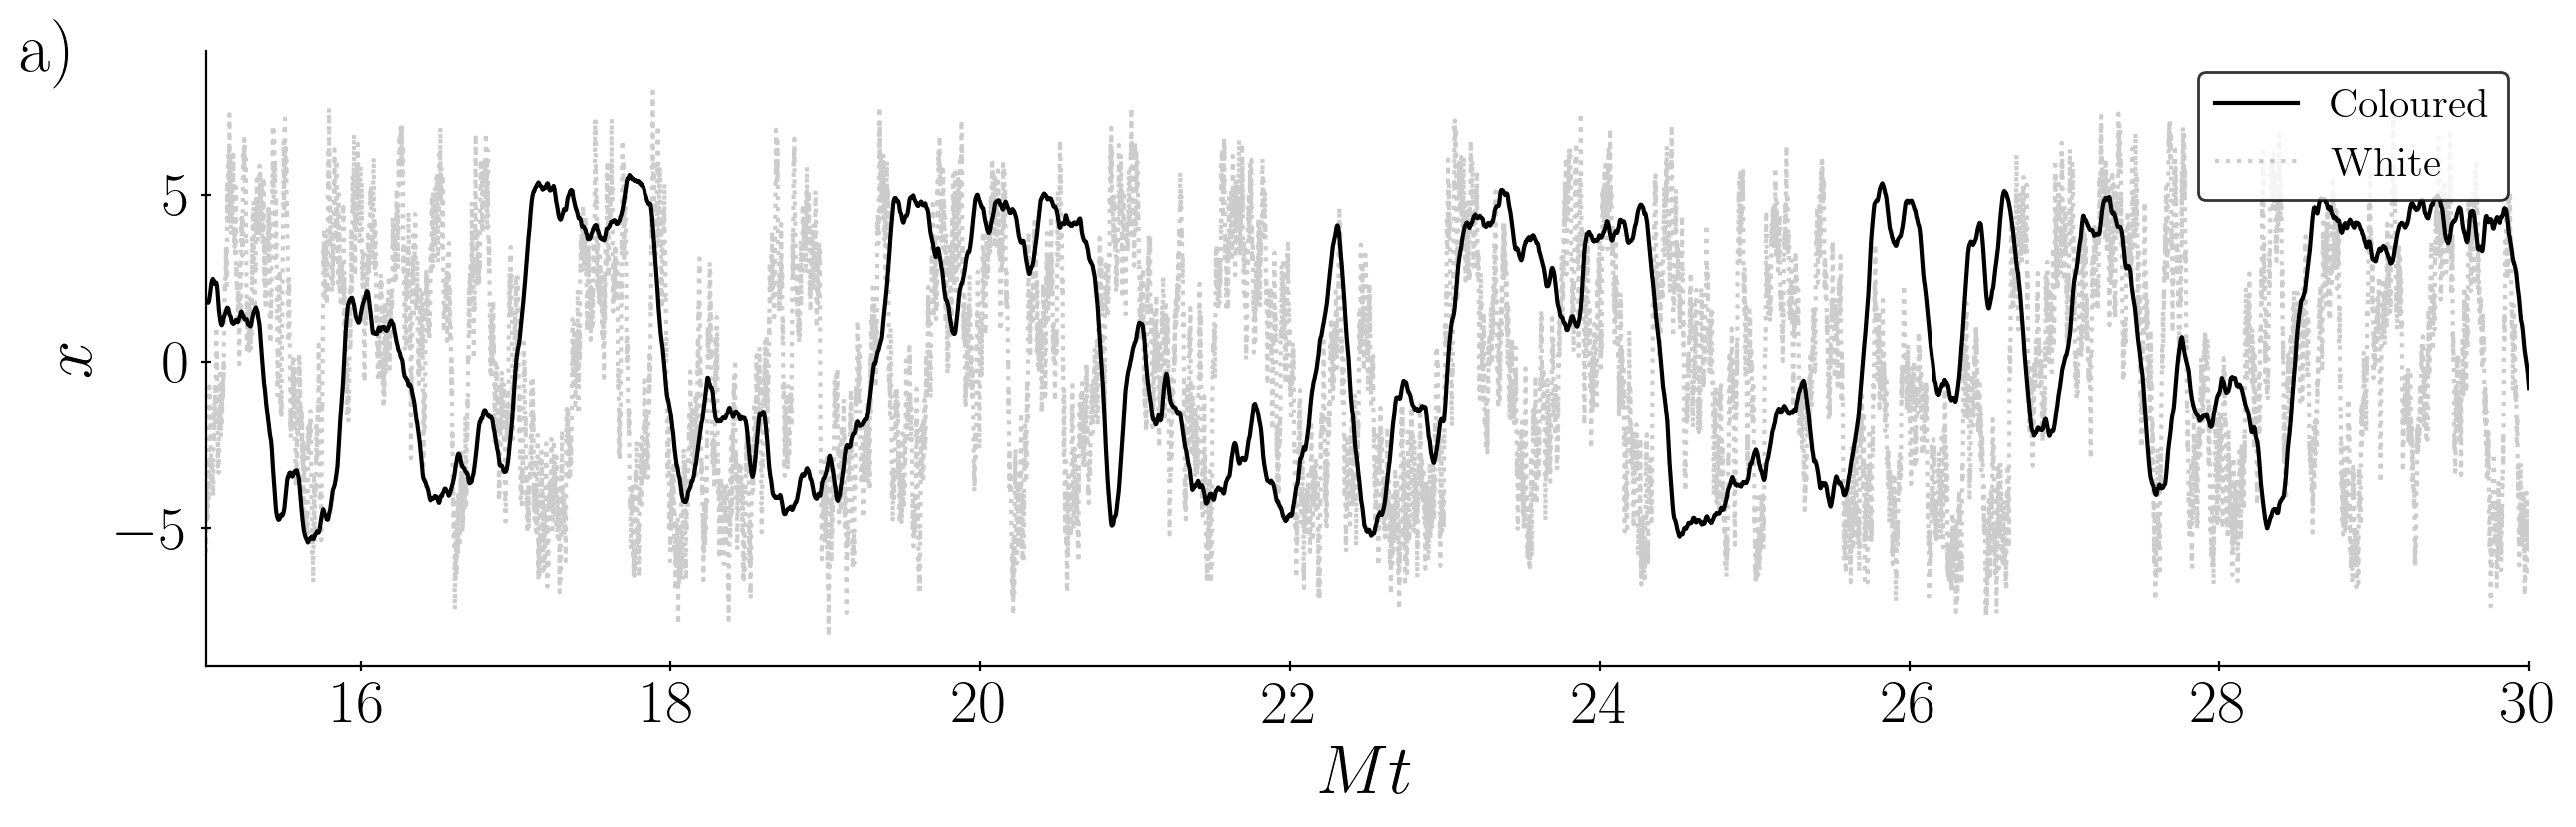

In [36]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(results_t * M, results_x_coloured[:, 100],  c='black', linestyle='-', label='Coloured')
ax.plot(results_t * M, results_x_white[:, 250],  c='black', linestyle=':', alpha=0.2, label='White')
ax.set_xlim([150 * M, 300 * M])
ax.set_xlabel('$M t$', fontsize=25)
ax.set_ylabel('$x$', fontsize=25)

ax.tick_params(axis="x", which="major", labelsize=22)
ax.tick_params(axis="y", which="major", labelsize=22)

ax.text(-0.08, 1.05, "a)", transform=ax.transAxes, fontsize=25, fontweight="bold", va="top", ha="left")

ax.tick_params(axis='both')
ax.legend(edgecolor='black', loc="upper right", fontsize=15)
plt.savefig('../figures/fig_3a.svg', bbox_inches='tight', dpi=200, transparent=True);

In [ ]:
# fig, ax = plt.subplots(figsize=(4, 2))
# ax.plot(results_t * M, results_x_coloured[:, 30],  c='purple', alpha=0.5, label='Coloured env')
# ax.plot(results_t * M, results_x_white[:, 30],  c='purple', alpha=0.1, linestyle=':', label='White env')
# ax.set_xlim([100 * M, 200 * M])
# ax.set_xlabel('$t$')
# ax.set_ylabel(r'$x_{k,ij}$')
# ax.tick_params(axis='both')
# ax.legend(edgecolor='black')
# plt.savefig('../figures/graphical_abstract_panel.svg', bbox_inches='tight', dpi=200, transparent=True);

# t_eval = 200 
# x_vals = np.linspace(-7.5, 7.5, 500)
# 
# fig, ax = plt.subplots(figsize=(4, 2), sharey=True, sharex=True)
# 
# ax.plot(x_vals, lib.two_patch_steady_state_density_x_white_noise(x_vals, M=M, D=D_white), linewidth=2.0, c='purple', alpha=0.2, linestyle='--')
# ax.plot(x_vals, lib.two_patch_steady_state_density_x_coloured_noise(x_vals, M=M, D=D_coloured, lamb=lamb), linewidth=2.0, c='purple', alpha=0.5)
# ax.set_ylabel(r"$\rho(x)$")
# ax.set_xlabel(r"$x_{k,ij}$")
# plt.savefig('../figures/graphical_abstract_panel_2.svg', bbox_inches='tight', dpi=200, transparent=True);

### Figure 2b)

tM = 20.0


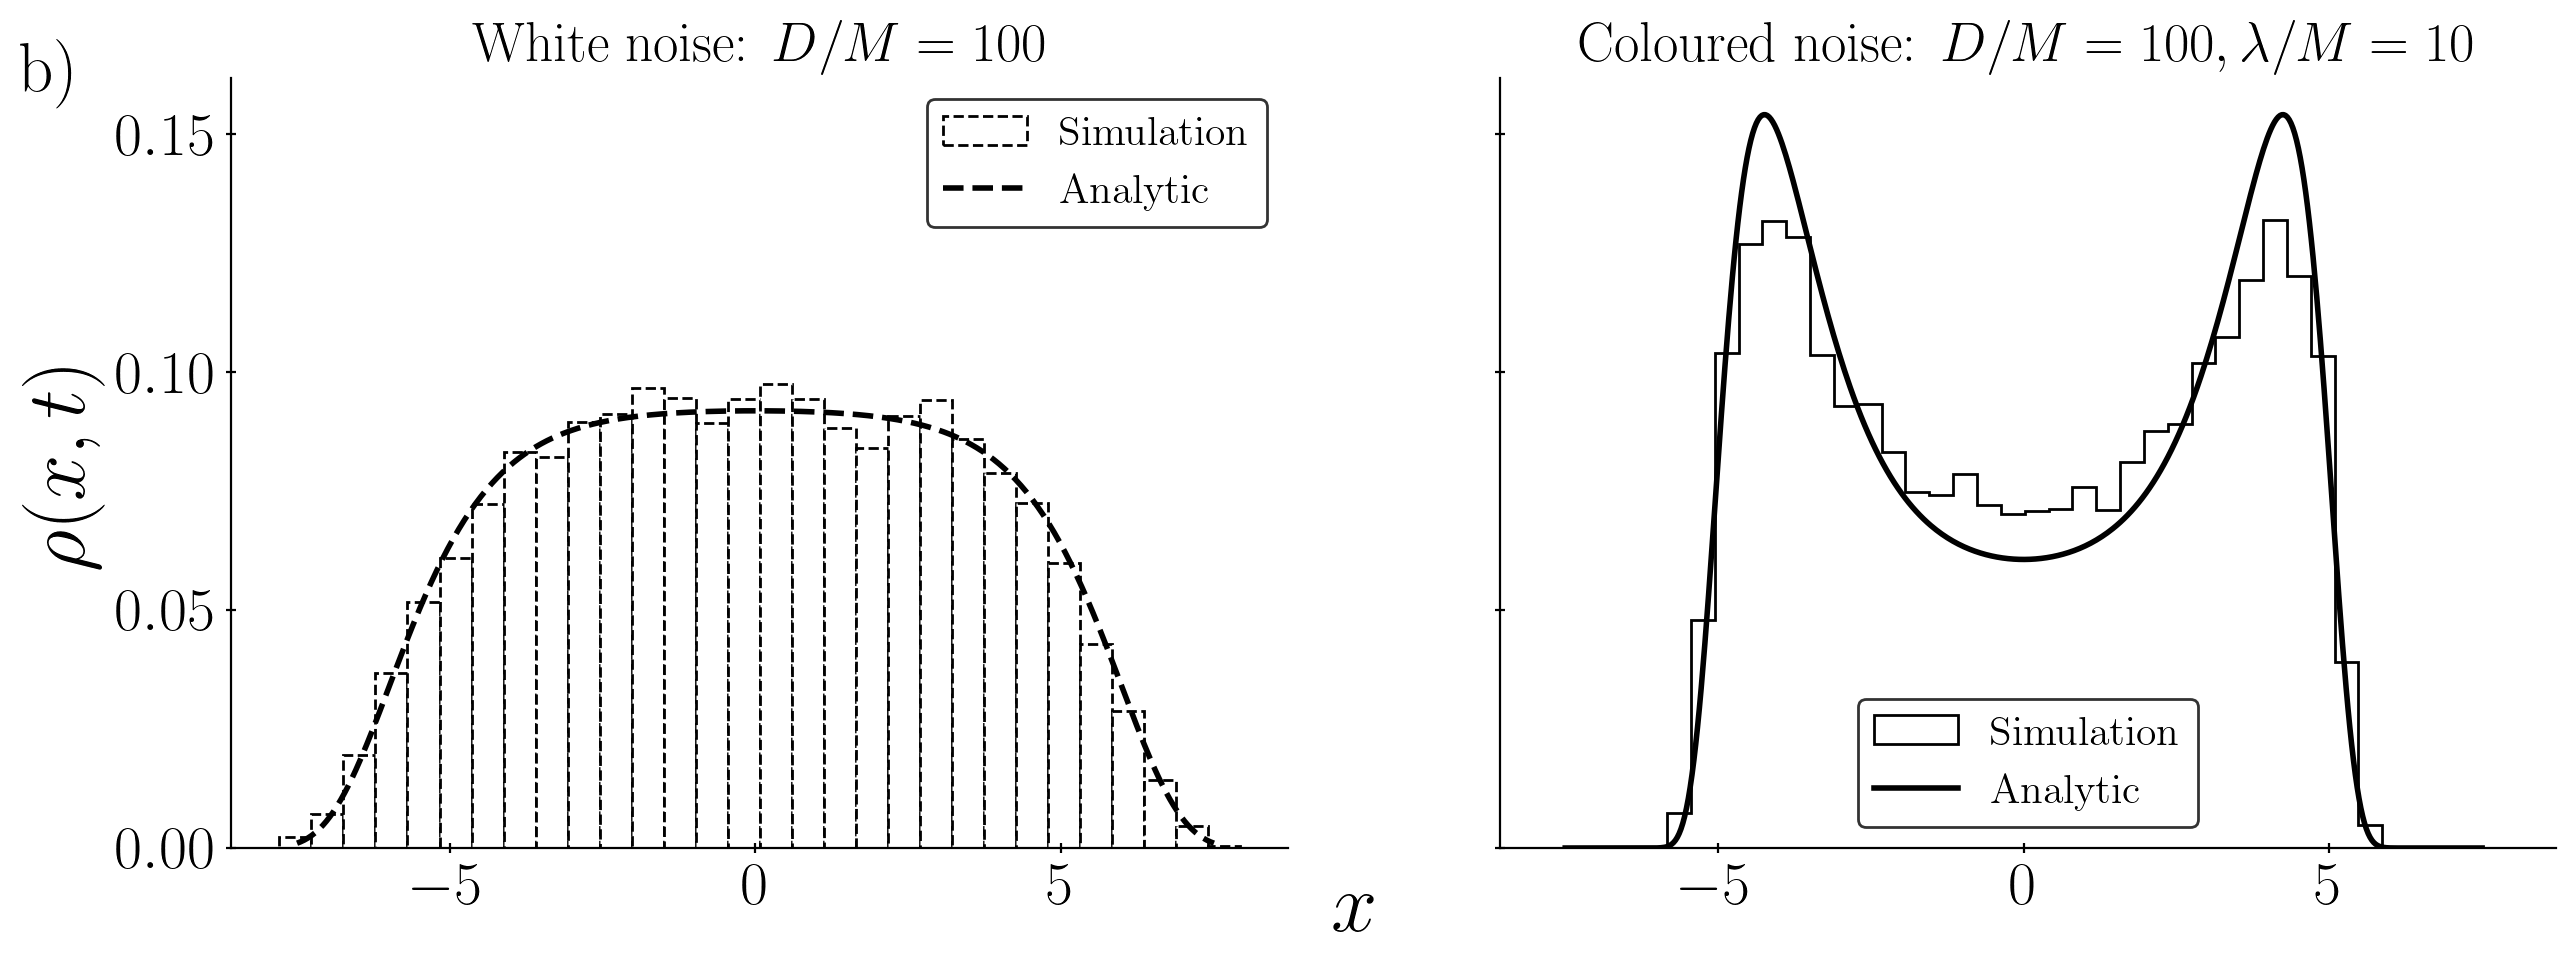

In [31]:
t_eval = 200 
x_vals = np.linspace(-7.5, 7.5, 500)
print(f"tM = {t_eval * M}")

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True, sharex=True)

ax[0].hist(results_x_white[np.argmin(np.abs(results_t - t_eval))], bins=30, density=True, color='white', edgecolor='black', linestyle='--', linewidth=1, label='Simulation')
ax[0].plot(x_vals, lib.two_patch_steady_state_density_x_white_noise(x_vals, M=M, D=D_white), linewidth=2.0, c='black', alpha=1, linestyle='--', label='Analytic')
ax[0].legend(edgecolor='black', loc='upper right', fontsize=15)
ax[0].set_title(rf"White noise: $D/M  = {D_white/M:.0f}$", fontsize=20)
ax[0].set_ylabel("$\\rho(x, t)$", fontsize=30)

ax[1].hist(results_x_coloured[np.argmin(np.abs(results_t - t_eval))], bins=30, density=True, color='white', edgecolor='black', histtype='step', label='Simulation') 
ax[1].plot(x_vals, lib.two_patch_steady_state_density_x_coloured_noise(x_vals, M=M, D=D_coloured, lamb=lamb), linewidth=2.0, c='black', alpha=1, label='Analytic')
ax[1].legend(edgecolor='black', loc='upper right')
ax[1].set_title(rf"Coloured noise: $D/M = {D_coloured/M:.0f}, \lambda/M = {lamb/M:.0f}$", fontsize=20)

ax[0].tick_params(axis='both', labelsize=20)
ax[1].tick_params(axis='both', labelsize=20)
ax[1].legend(edgecolor='black', fontsize=15)

for axes in ax:
    axes.tick_params(axis="x", which="major", labelsize=22)
    axes.tick_params(axis="y", which="major", labelsize=22)
    
ax[0].text(-0.2, 1.05, "b)", transform=ax[0].transAxes, fontsize=25, fontweight="bold", va="top", ha="left")

fig.supxlabel("$x$", fontsize=30)
plt.savefig('../figures/fig_3b.svg', bbox_inches='tight', dpi=200, transparent=True);

### Figure 2c)

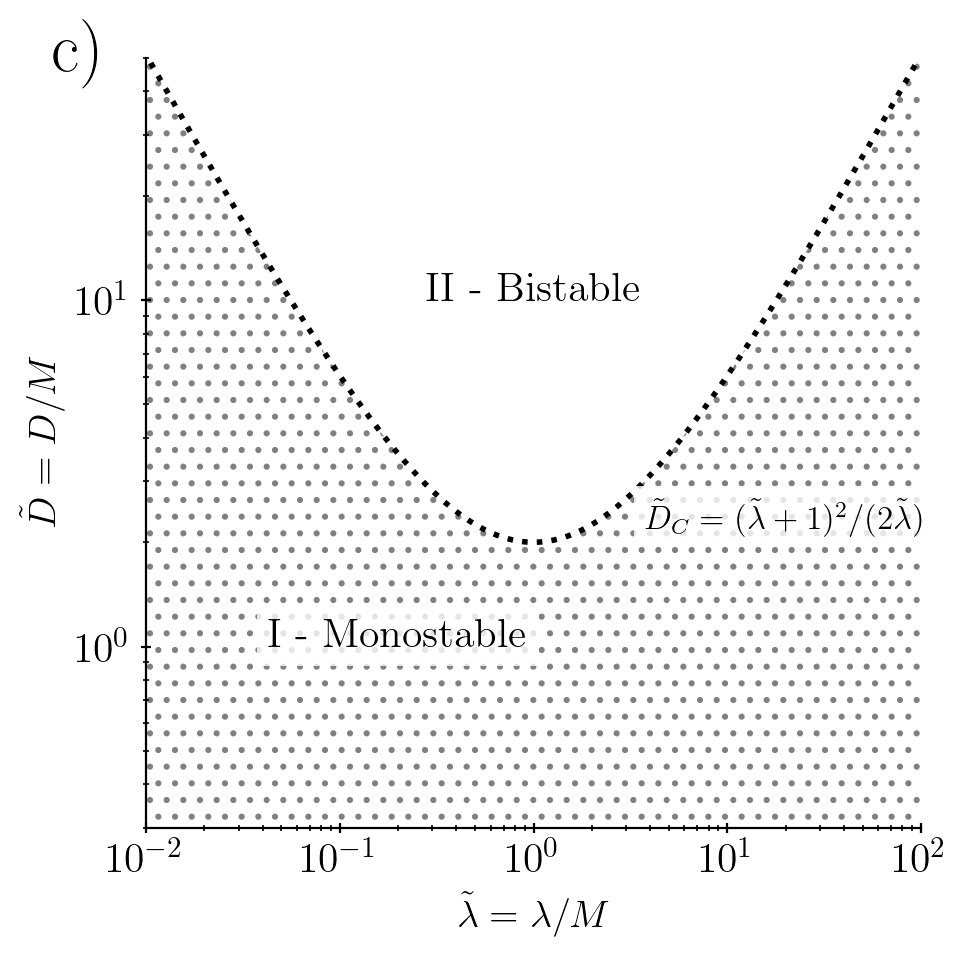

In [29]:
fig, ax = plt.subplots(figsize=(5, 5))

lamb_tilde = np.logspace(-3, 3, 1000)
D_crit = (lamb_tilde  + 1)**2 / (2 * lamb_tilde )

ax.plot(lamb_tilde, D_crit, 'k:', linewidth=2)
ax.fill_between(lamb_tilde, 0, D_crit, hatch='..', facecolor='white', edgecolor='gray', linewidth=0)

ax.set_xlabel(r'$\tilde{\lambda} = \lambda/M$')
ax.set_ylabel(r'$\tilde{D} = D/M$')
ax.set_xlim(0.01, 100)
ax.set_ylim(0.3, 50)
ax.set_xscale('log')
ax.set_yscale('log')

ax.text(1, 10, "II - Bistable", fontsize=15, weight='bold', c='black', ha='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
ax.text(0.2, 1, "I - Monostable", fontsize=15, weight='bold', c='black', ha='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
ax.text(20, 2.2, r"$\tilde{D}_C = (\tilde{\lambda} + 1)^2 / (2 \tilde{\lambda})$", fontsize=12, weight='bold', c='black', ha='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8));

ax.text(-0.12, 1.05, "c)", transform=ax.transAxes, fontsize=25, fontweight="bold", va="top", ha="left")

plt.savefig('../figures/fig_3c.svg', bbox_inches='tight', dpi=200, transparent=True);

## SI

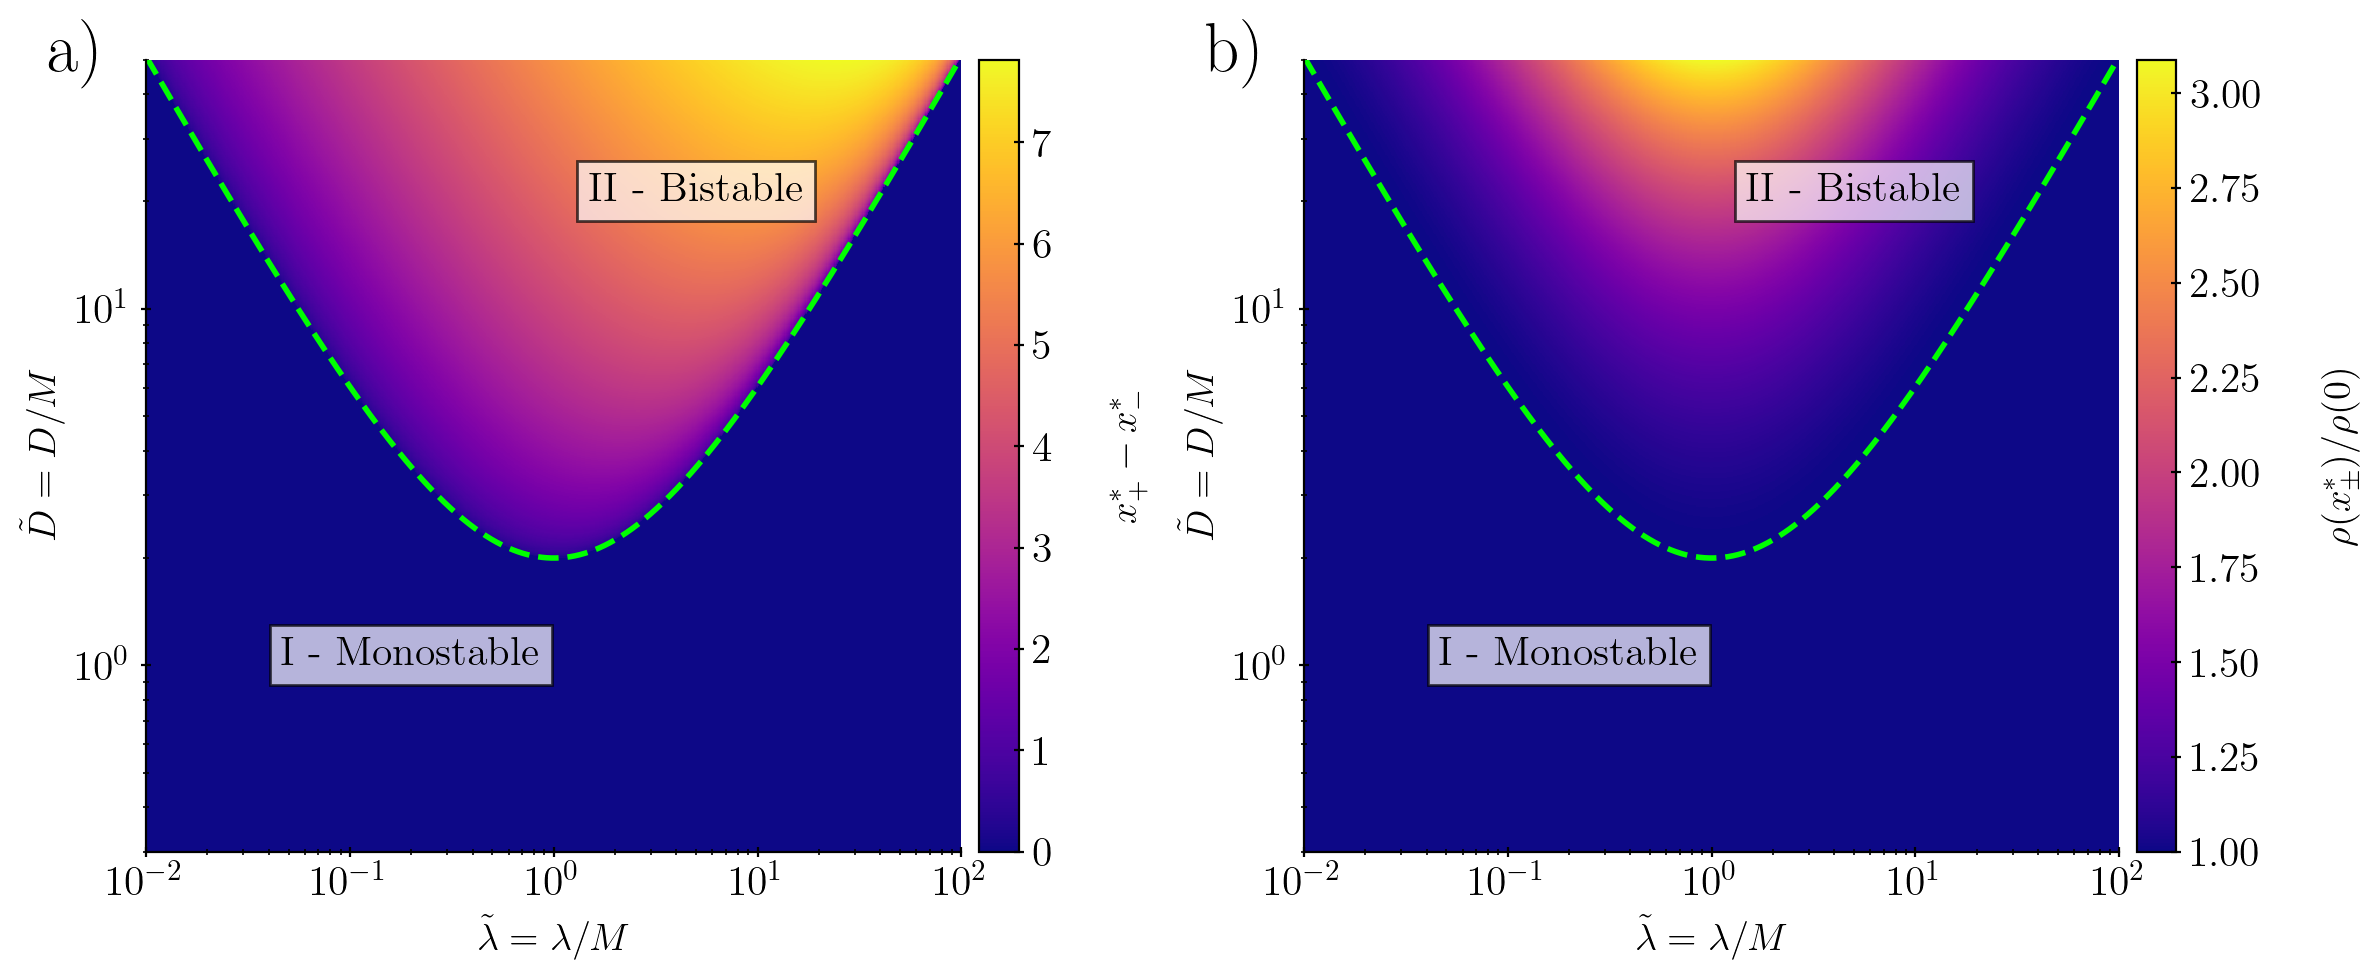

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), layout='tight')

lam_min, lam_max = 0.01, 100
D_min, D_max = 0.3, 50

lamb_tilde = np.logspace(np.log10(lam_min), np.log10(lam_max), 1200)
D_crit = (lamb_tilde + 1)**2 / (2 * lamb_tilde)

n_lam, n_D = 700, 700
lam_edges = np.logspace(np.log10(lam_min), np.log10(lam_max), n_lam + 1)
D_edges   = np.logspace(np.log10(D_min),  np.log10(D_max),  n_D + 1)

lam_cent = np.sqrt(lam_edges[:-1] * lam_edges[1:])
D_cent   = np.sqrt(D_edges[:-1]   * D_edges[1:])

LAM, DD = np.meshgrid(lam_cent, D_cent) 

arg = np.sqrt(2.0 * DD * LAM) - LAM
Dcrit_grid = (LAM + 1.0)**2 / (2.0 * LAM)
mask_below = DD < Dcrit_grid

distance = np.zeros_like(arg)
mask_valid = (~mask_below) & (arg >= 1.0)
distance[mask_valid] = 2 * np.arccosh(arg[mask_valid])

ratio = np.ones_like(arg)
ratio[mask_valid] = lib.unnormalized_two_patch_steady_state_density_x_coloured_noise(np.arccosh(arg[mask_valid]), M=1, D=DD[mask_valid], lamb=LAM[mask_valid])/lib.unnormalized_two_patch_steady_state_density_x_coloured_noise(0, M=1, D=DD[mask_valid], lamb=LAM[mask_valid])

labels = [r'$x^{*}_{+} - x^{*}_{-}$', r'$\rho(x^{*}_{\pm})/\rho(0)$']
to_plot = [distance, ratio]
panel_letters = ["a)", "b)"]
for i, axes in enumerate(ax):

        hm = axes.pcolormesh(lam_edges, D_edges, to_plot[i], shading="auto", cmap="plasma", rasterized=True)

        line, = axes.plot(lamb_tilde, D_crit, color="lime", linestyle="--", linewidth=2)

        axes.set_xlabel(r'$\tilde{\lambda} = \lambda/M$')
        axes.set_ylabel(r'$\tilde{D} = D/M$')
        axes.set_xlim(lam_min, lam_max)
        axes.set_ylim(D_min, D_max)
        axes.set_xscale('log')
        axes.set_yscale('log')

        axes.text(5, 20, "II - Bistable", fontsize=15, weight='bold', c='black', ha='center', 
                bbox=dict(facecolor='white', edgecolor='black', alpha=0.7))
        axes.text(0.2, 1, "I - Monostable", fontsize=15, weight='bold', c='black', ha='center',
                bbox=dict(facecolor='white', edgecolor='black', alpha=0.7))
        
        axes.text(-0.12, 1.05, panel_letters[i], transform=axes.transAxes, fontsize=25, fontweight="bold", va="top", ha="left")

        cbar = fig.colorbar(hm, ax=axes, pad=0.02, fraction=0.05)
        cbar.set_label(labels[i], labelpad=20.0)

plt.savefig('../figures/SI_extra_phase_diagrams.pdf', bbox_inches='tight', dpi=150, transparent=True);